In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [5]:
df= pd.read_csv("homework_3.1.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    100 non-null    int64  
 1   value1  100 non-null    float64
 2   value2  100 non-null    float64
 3   value3  100 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 3.3 KB


In [7]:

event_time = 50
df['after_event'] = (df['time'] >= event_time).astype(int)
df['time_after_event'] = np.where(
    df['time'] >= event_time,
    df['time'] - event_time,
    0
)
X1 = df[['time', 'after_event']]
X1 = sm.add_constant(X1)

y = df['value1']

model1 = sm.OLS(y, X1).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     90.57
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           6.48e-23
Time:                        14:41:30   Log-Likelihood:                -160.63
No. Observations:                 100   AIC:                             327.3
Df Residuals:                      97   BIC:                             335.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.4439      0.271     -1.640      

In [8]:
X2 = df[['time', 'after_event', 'time_after_event']]
X2 = sm.add_constant(X2)

model2 = sm.OLS(y, X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     120.2
Date:                Thu, 04 Jun 2026   Prob (F-statistic):           2.18e-32
Time:                        14:43:22   Log-Likelihood:                -135.33
No. Observations:                 100   AIC:                             278.7
Df Residuals:                      96   BIC:                             289.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.8464      0.266  

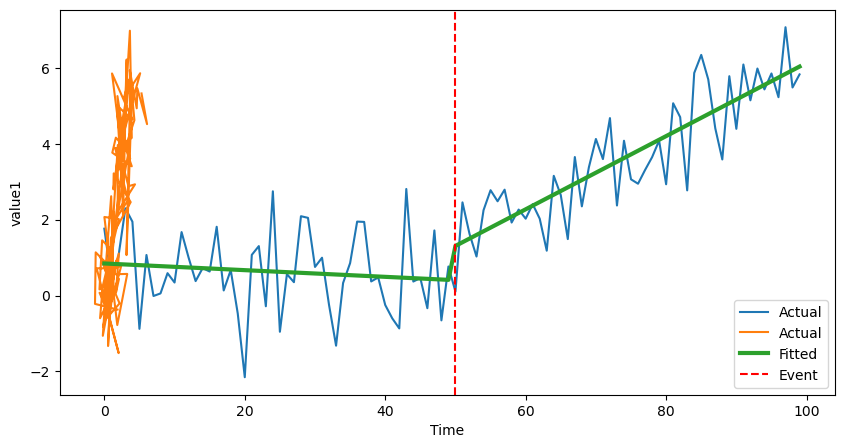

In [12]:
import matplotlib.pyplot as plt

df['predicted'] = model2.predict(X2)

plt.figure(figsize=(10,5))

plt.plot(df['time'], df['value1'], df['value2'], df['value3'], label='Actual')
plt.plot(df['time'], df['predicted'], label='Fitted', linewidth=3)

plt.axvline(event_time, color='red', linestyle='--', label='Event')

plt.xlabel("Time")
plt.ylabel("value1")
plt.legend()
plt.show()

In [11]:
import statsmodels.api as sm

variables = ['value1', 'value2', 'value3']

results = []

for var in variables:

    X = df[['time', 'after_event']]
    X = sm.add_constant(X)

    y = df[var]

    model = sm.OLS(y, X).fit()

    coef = model.params['after_event']
    pval = model.pvalues['after_event']

    results.append([var, coef, pval])

results_df = pd.DataFrame(
    results,
    columns=['Variable', 'After_Event_Coefficient', 'P_Value']
)

print(results_df)

  Variable  After_Event_Coefficient   P_Value
0   value1                 0.850813  0.085607
1   value2                 0.682746  0.113103
2   value3                 1.767254  0.000033


In [13]:
import numpy as np
import statsmodels.api as sm
import pandas as pd

event_time = 50

df['after_event'] = (df['time'] >= event_time).astype(int)

df['time_after_event'] = np.where(
    df['time'] >= event_time,
    df['time'] - event_time,
    0
)

variables = ['value1', 'value2', 'value3']

results = []

for var in variables:

    X = df[['time', 'after_event', 'time_after_event']]
    X = sm.add_constant(X)

    y = df[var]

    model = sm.OLS(y, X).fit()

    coef = model.params['time_after_event']
    pval = model.pvalues['time_after_event']

    results.append([var, coef, pval])

results_df = pd.DataFrame(
    results,
    columns=['Variable', 'Slope_Change_Coefficient', 'P_Value']
)

print(results_df)

  Variable  Slope_Change_Coefficient       P_Value
0   value1                  0.105325  3.602073e-12
1   value2                  0.036921  1.181130e-02
2   value3                  0.050695  2.076610e-04


In [18]:
df_a= pd.read_csv("homework_3.2.a.csv")
df_b= pd.read_csv("homework_3.2.b.csv")
print(df_a.head())
print(df_b.head())

   group1  time1  outcome1
0       0      0  0.882026
1       0      1  1.600079
2       0      0  0.489369
3       0      1  2.520447
4       0      0  0.933779
   group2  time2  outcome2
0       0      0  0.667155
1       0      1  2.470969
2       0      0 -0.506778
3       0      1  1.525657
4       0      0  0.273664


In [ ]:
df_a['interaction'] = df_a['group1'] * df_a['time1']

model_a = smf.ols(
    'outcome1 ~ group1 + time1 + interaction',
    data=df_a
).fit()

print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:               outcome1   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2964.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:57:57   Log-Likelihood:                -712.28
No. Observations:                1000   AIC:                             1433.
Df Residuals:                     996   BIC:                             1452.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.0258      0.031     -0.829      

In [22]:
df_b['interaction'] = df_b['group2'] * df_b['time2']

model_b = smf.ols(
    'outcome2 ~ group2 + time2 + interaction',
    data=df_b
).fit()

print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:               outcome2   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     653.6
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          9.62e-235
Time:                        14:59:51   Log-Likelihood:                -1567.5
No. Observations:                1000   AIC:                             3143.
Df Residuals:                     996   BIC:                             3163.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.1021      0.073      1.392      